In [2]:
!pip install -U transformers --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 88.8 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.0a1 which is incompatible.


In [3]:
!pip install evaluate --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 43.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.1.0 which is incompatible.
cudf-polars-cu12 25.6.0 requires pylibcudf-cu12==25.6.*,

In [4]:
import os
import pandas as pd
import numpy as np
import evaluate  # ✅ Fixed: Use evaluate instead of load_metric
from datasets import Dataset
from transformers import (
    AutoFeatureExtractor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, TaskType
from PIL import Image
import torch

2025-10-23 14:26:42.703484: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761229602.928555      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761229602.998378      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
# 1️⃣ PATHS
data_dir = "/kaggle/input/eurosat-dataset/EuroSAT"
train_csv = os.path.join(data_dir, "train.csv")
val_csv = os.path.join(data_dir, "validation.csv")
test_csv = os.path.join(data_dir, "test.csv")

In [6]:
test_csv

'/kaggle/input/eurosat-dataset/EuroSAT/test.csv'

In [7]:
# 2️⃣ LOAD CSVs
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

In [8]:
train_df.head()

,Unnamed: 0,Filename,Label,ClassName
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop
3,2223,Industrial/Industrial_453.jpg,4,Industrial
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation


In [9]:
# ✅ Fix: Rename Label to labels BEFORE creating datasets
train_df = train_df.rename(columns={"Label": "labels"})
val_df = val_df.rename(columns={"Label": "labels"})
test_df = test_df.rename(columns={"Label": "labels"})

In [10]:
# Fix image paths
train_df["image_path"] = train_df["Filename"].apply(lambda x: os.path.join(data_dir, x))
val_df["image_path"] = val_df["Filename"].apply(lambda x: os.path.join(data_dir, x))
test_df["image_path"] = test_df["Filename"].apply(lambda x: os.path.join(data_dir, x))

In [11]:
train_df.head()

,Unnamed: 0,Filename,labels,ClassName,image_path
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop,/kaggle/input/eurosat-dataset/EuroSAT/AnnualCr...
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation,/kaggle/input/eurosat-dataset/EuroSAT/Herbaceo...
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop,/kaggle/input/eurosat-dataset/EuroSAT/Permanen...
3,2223,Industrial/Industrial_453.jpg,4,Industrial,/kaggle/input/eurosat-dataset/EuroSAT/Industri...
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation,/kaggle/input/eurosat-dataset/EuroSAT/Herbaceo...


In [12]:
from datasets import Dataset, DatasetDict

# 1️⃣ Keep only the columns we need
train_pd = train_df[["image_path", "labels"]].rename(columns={"image_path": "image"})
val_pd   = val_df[["image_path", "labels"]].rename(columns={"image_path": "image"})
test_pd  = test_df[["image_path", "labels"]].rename(columns={"image_path": "image"})

In [13]:
train_pd.head()

,image,labels
0,/kaggle/input/eurosat-dataset/EuroSAT/AnnualCr...,0
1,/kaggle/input/eurosat-dataset/EuroSAT/Herbaceo...,2
2,/kaggle/input/eurosat-dataset/EuroSAT/Permanen...,6
3,/kaggle/input/eurosat-dataset/EuroSAT/Industri...,4
4,/kaggle/input/eurosat-dataset/EuroSAT/Herbaceo...,2


In [14]:
# Make sure labels are plain Python integers
train_pd["labels"] = train_pd["labels"].astype(int)
val_pd["labels"] = val_pd["labels"].astype(int)
test_pd["labels"] = test_pd["labels"].astype(int)

# Convert labels to strings for ClassLabel names
label_names = [str(i) for i in sorted(train_pd["labels"].unique())]

In [15]:
from datasets import Dataset, Features, ClassLabel, Image

features = Features({
    "image": Image(),  # automatically loads from file path
    "labels": ClassLabel(names=label_names),
})

train_ds = Dataset.from_pandas(train_pd, features=features, preserve_index=False)
val_ds = Dataset.from_pandas(val_pd, features=features, preserve_index=False)
test_ds = Dataset.from_pandas(test_pd, features=features, preserve_index=False)


In [16]:
train_ds

Dataset({
    features: ['image', 'labels'],
    num_rows: 18900
})

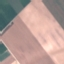

In [17]:
train_ds[0]['image']

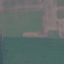

In [18]:
test_ds[0]['image']

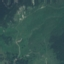

In [19]:
val_ds[0]['image']

In [20]:
# 3️⃣ Combine into a single DatasetDict
dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

# Check
print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 18900
    })
    validation: Dataset({
        features: ['image', 'labels'],
        num_rows: 5400
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 2700
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=64x64 at 0x7BF920F4C050>, 'labels': 0}


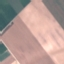

In [21]:
image=dataset["train"][0]['image']
image
# labels=dataset["train"][0]['labels']
# labels

In [22]:
from transformers import AutoImageProcessor, SwinForImageClassification

model_name = "microsoft/swin-base-patch4-window7-224"

# 1️⃣ Load image processor (handles resizing, normalization, etc.)
image_processor = AutoImageProcessor.from_pretrained(model_name)

# 2️⃣ Load pre-trained model
model = SwinForImageClassification.from_pretrained(
    model_name,
    num_labels=10,
    ignore_mismatched_sizes=True,
    device_map="auto"
)


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-base-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 1024]) in the checkpoint and torch.Size([10, 1024]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
image_processor(image, return_tensors='pt')


{'pixel_values': tensor([[[[-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          [-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          [-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          ...,
          [ 1.1358,  1.1358,  1.1358,  ...,  1.8037,  1.8037,  1.8037],
          [ 1.1529,  1.1529,  1.1529,  ...,  1.8037,  1.8037,  1.8037],
          [ 1.1700,  1.1700,  1.1700,  ...,  1.8037,  1.8037,  1.8037]],

         [[-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          [-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          [-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          ...,
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031],
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031],
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031]],

         [[-0.0267, -0.0267, -0.0267,  ...,  0.2348,  0.2173,  0.2173],
          [-0

In [24]:
def process_example(example):
    inputs = image_processor(example['image'], return_tensors='pt')
    inputs['labels'] = example['labels']
    return inputs

In [25]:
process_example(dataset['train'][0])

{'pixel_values': tensor([[[[-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          [-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          [-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          ...,
          [ 1.1358,  1.1358,  1.1358,  ...,  1.8037,  1.8037,  1.8037],
          [ 1.1529,  1.1529,  1.1529,  ...,  1.8037,  1.8037,  1.8037],
          [ 1.1700,  1.1700,  1.1700,  ...,  1.8037,  1.8037,  1.8037]],

         [[-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          [-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          [-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          ...,
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031],
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031],
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031]],

         [[-0.0267, -0.0267, -0.0267,  ...,  0.2348,  0.2173,  0.2173],
          [-0

In [26]:
def transform(example_batch):
    # Take a list of PIL images and turn them to pixel values
    inputs = image_processor([x for x in example_batch['image']], return_tensors='pt')

    # Don't forget to include the labels!
    inputs['labels'] = example_batch['labels']
    return inputs

In [27]:
processed_dataset = dataset.with_transform(transform)

In [28]:
processed_dataset['train'][0:2]

{'pixel_values': tensor([[[[-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          [-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          [-0.8507, -0.8507, -0.8507,  ..., -0.0972, -0.1143, -0.1143],
          ...,
          [ 1.1358,  1.1358,  1.1358,  ...,  1.8037,  1.8037,  1.8037],
          [ 1.1529,  1.1529,  1.1529,  ...,  1.8037,  1.8037,  1.8037],
          [ 1.1700,  1.1700,  1.1700,  ...,  1.8037,  1.8037,  1.8037]],

         [[-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          [-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          [-0.2150, -0.2150, -0.2150,  ..., -0.0049, -0.0224, -0.0224],
          ...,
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031],
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031],
          [ 0.8004,  0.8004,  0.8004,  ...,  1.2031,  1.2031,  1.2031]],

         [[-0.0267, -0.0267, -0.0267,  ...,  0.2348,  0.2173,  0.2173],
          [-0

In [29]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./swin-eurosat-v1",            # where to save model + logs
    per_device_train_batch_size=16,    # try 16; reduce if you get CUDA OOM
    per_device_eval_batch_size=16,
    num_train_epochs=3,                # start small (3–5 usually works well)
    learning_rate=5e-5,                # standard fine-tuning LR
    eval_strategy="epoch",       # evaluate at the end of each epoch
    save_strategy="epoch",             # save model after each epoch
    logging_dir="./logs",              # where to save logs for TensorBoard
    logging_steps=50,                  
    load_best_model_at_end=True,       # keeps the best checkpoint
    metric_for_best_model="accuracy",  # optional if you define metrics
    remove_unused_columns=False,       # ✅ must be False when using with_transform()
    report_to='tensorboard',
)


In [30]:
import numpy as np
import evaluate

# ✅ Load the accuracy metric
accuracy_metric = evaluate.load("accuracy")

# ✅ Define a function to compute metrics after each evaluation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred  # unpack (logits, labels)
    preds = np.argmax(predictions, axis=1)  # take the class with max logit score
    return accuracy_metric.compute(predictions=preds, references=labels)


In [31]:
from transformers import Trainer

trainer = Trainer(
    model=model,                                # your Swin model
    args=training_args,                         # the TrainingArguments block you defined
    train_dataset=processed_dataset["train"],   # your processed train split
    eval_dataset=processed_dataset["validation"],  # your processed validation split
    compute_metrics=compute_metrics,            # accuracy metric function
    processing_class=image_processor,                  # ✅ renamed from feature_extractor (for saving)
)


In [33]:
# Replace with your latest checkpoint path

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,0.082400,0.101187,0.975926
2,0.052700,0.052423,0.989074
3,0.011900,0.060363,0.987037


TrainOutput(global_step=3546, training_loss=0.0723987766134448, metrics={'train_runtime': 2873.7026, 'train_samples_per_second': 19.731, 'train_steps_per_second': 1.234, 'total_flos': 4.4426129230393344e+18, 'train_loss': 0.0723987766134448, 'epoch': 3.0})

In [34]:
results_train = trainer.evaluate(processed_dataset['train'])

In [35]:
results_train

{'eval_loss': 0.009523831307888031,
 'eval_accuracy': 0.9971428571428571,
 'eval_runtime': 327.9838,
 'eval_samples_per_second': 57.625,
 'eval_steps_per_second': 3.604,
 'epoch': 3.0}

In [36]:
results_test = trainer.evaluate(processed_dataset['test'])

In [37]:
results_test

{'eval_loss': 0.05882428586483002,
 'eval_accuracy': 0.9885185185185185,
 'eval_runtime': 60.4045,
 'eval_samples_per_second': 44.699,
 'eval_steps_per_second': 2.798,
 'epoch': 3.0}

In [38]:
trainer.save_model("./swin-eurosat-v1-finetuned_model")
image_processor.save_pretrained("./swin-eurosat-v1-finetuned_processor")


['./swin-eurosat-v1-finetuned_processor/preprocessor_config.json']

In [39]:
from shutil import make_archive

# Zip the model folder
make_archive("swin-eurosat-finetuned", 'zip', "./swin-eurosat-v1-finetuned_model")

# Zip the processor folder (optional, but recommended)
make_archive("image-processor", 'zip', "./swin-eurosat-v1-finetuned_processor")


'/kaggle/working/image-processor.zip'